In [1]:
!pip install yfinance ta-lib matplotlib pandas numpy seaborn

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 경로 지정 (Windows 기준, 나눔고딕 예시)
font_path = "C:/Windows/Fonts/malgun.ttf"  # '맑은 고딕' 사용
font_prop = fm.FontProperties(fname=font_path)

plt.rc("font", family=font_prop.get_name())  # Matplotlib 기본 폰트 설정

In [3]:
import yfinance as yf
import talib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_stock_data(ticker="AAPL", period="6mo", interval="1d"):
    stock = yf.Ticker(ticker)
    df = stock.history(period=period, interval=interval)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.dropna(inplace=True)
    return df

In [4]:
def evaluate_indicator(value, thresholds):
    if value >= thresholds['over3']:
        return "고평가 3단계"
    elif value >= thresholds['over2']:
        return "고평가 2단계"
    elif value >= thresholds['over1']:
        return "고평가 1단계"
    elif value <= thresholds['under3']:
        return "저평가 3단계"
    elif value <= thresholds['under2']:
        return "저평가 2단계"
    elif value <= thresholds['under1']:
        return "저평가 1단계"
    else:
        return "중립"

In [5]:
def compute_indicators(df):
    indicators = {}
    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume']

    # 볼린저 밴드
    upper, middle, lower = talib.BBANDS(close, timeperiod=20)
    indicators['Bollinger'] = {'upper': upper, 'middle': middle, 'lower': lower, 'eval': evaluate_indicator(close.iloc[-1], {
        'over3': upper.iloc[-1]*1.01,
        'over2': upper.iloc[-1],
        'over1': middle.iloc[-1]*1.05,
        'under3': lower.iloc[-1]*0.99,
        'under2': lower.iloc[-1],
        'under1': middle.iloc[-1]*0.95
    })}

    # MACD
    macd, signal, hist = talib.MACD(close)
    indicators['MACD'] = {'macd': macd, 'signal': signal, 'hist': hist, 'eval': evaluate_indicator(hist.iloc[-1], {
        'over3': 2.0, 'over2': 1.0, 'over1': 0.5,
        'under3': -2.0, 'under2': -1.0, 'under1': -0.5
    })}

    # SMA
    sma20 = talib.SMA(close, timeperiod=20)
    sma50 = talib.SMA(close, timeperiod=50)
    indicators['SMA'] = {'sma20': sma20, 'sma50': sma50, 'eval': evaluate_indicator(sma20.iloc[-1] - sma50.iloc[-1], {
        'over3': 15, 'over2': 10, 'over1': 5,
        'under3': -15, 'under2': -10, 'under1': -5
    })}

    # RSI
    rsi = talib.RSI(close)
    indicators['RSI'] = {'rsi': rsi, 'eval': evaluate_indicator(rsi.iloc[-1], {
        'over3': 85, 'over2': 75, 'over1': 70,
        'under3': 15, 'under2': 25, 'under1': 30
    })}

    # ADX
    adx = talib.ADX(high, low, close)
    indicators['ADX'] = {'adx': adx, 'eval': evaluate_indicator(adx.iloc[-1], {
        'over3': 50, 'over2': 40, 'over1': 30,
        'under3': 10, 'under2': 15, 'under1': 20
    })}

    # ATR
    atr = talib.ATR(high, low, close)
    indicators['ATR'] = {'atr': atr, 'eval': evaluate_indicator(atr.iloc[-1], {
        'over3': atr.mean() * 2.0,
        'over2': atr.mean() * 1.5,
        'over1': atr.mean() * 1.2,
        'under3': atr.mean() * 0.3,
        'under2': atr.mean() * 0.5,
        'under1': atr.mean() * 0.8
    })}

    # Stochastic
    slowk, slowd = talib.STOCH(high, low, close)
    indicators['Stochastic'] = {'slowk': slowk, 'slowd': slowd, 'eval': evaluate_indicator(slowk.iloc[-1], {
        'over3': 95, 'over2': 90, 'over1': 80,
        'under3': 5, 'under2': 10, 'under1': 20
    })}

    # CCI
    cci = talib.CCI(high, low, close)
    indicators['CCI'] = {'cci': cci, 'eval': evaluate_indicator(cci.iloc[-1], {
        'over3': 300, 'over2': 200, 'over1': 100,
        'under3': -300, 'under2': -200, 'under1': -100
    })}

    # MFI
    mfi = talib.MFI(high, low, close, volume)
    indicators['MFI'] = {'mfi': mfi, 'eval': evaluate_indicator(mfi.iloc[-1], {
        'over3': 90, 'over2': 80, 'over1': 75,
        'under3': 10, 'under2': 20, 'under1': 25
    })}

    # ROC
    roc = talib.ROC(close)
    indicators['ROC'] = {'roc': roc, 'eval': evaluate_indicator(roc.iloc[-1], {
        'over3': 30, 'over2': 20, 'over1': 10,
        'under3': -30, 'under2': -20, 'under1': -10
    })}

    # VWAP
    vwap = (close * volume).cumsum() / volume.cumsum()
    indicators['VWAP'] = {'vwap': vwap, 'eval': evaluate_indicator(close.iloc[-1] - vwap.iloc[-1], {
        'over3': 15, 'over2': 10, 'over1': 5,
        'under3': -15, 'under2': -10, 'under1': -5
    })}

    # 피보나치 되돌림
    max_price = close.max()
    min_price = close.min()
    diff = max_price - min_price
    retracement_levels = {
        '0.0%': max_price,
        '23.6%': max_price - 0.236 * diff,
        '38.2%': max_price - 0.382 * diff,
        '50.0%': max_price - 0.5 * diff,
        '61.8%': max_price - 0.618 * diff,
        '100.0%': min_price
    }
    current_price = close.iloc[-1]
    indicators['Fibonacci'] = {'levels': retracement_levels, 'eval': evaluate_indicator(current_price - retracement_levels['50.0%'], {
        'over3': diff * 0.4, 'over2': diff * 0.3, 'over1': diff * 0.2,
        'under3': -diff * 0.4, 'under2': -diff * 0.3, 'under1': -diff * 0.2
    })}

    return indicators, df

In [6]:
def plot_indicators(indicators, df):
    close = df['Close']
    date_index = df.index
    fig, axs = plt.subplots(nrows=12, ncols=1, figsize=(18, 48), sharex=True)

    titles = [
        "1. Bollinger Bands", "2. MACD", "3. SMA (20/50)", "4. RSI", "5. ADX", "6. ATR",
        "7. Stochastic Oscillator", "8. CCI", "9. MFI", "10. ROC", "11. VWAP", "12. Fibonacci Retracement"
    ]

    # 1
    axs[0].plot(date_index, close, label="종가")
    axs[0].plot(date_index, indicators['Bollinger']['upper'], label="Upper")
    axs[0].plot(date_index, indicators['Bollinger']['middle'], label="Middle")
    axs[0].plot(date_index, indicators['Bollinger']['lower'], label="Lower")
    axs[0].set_title(f"{titles[0]} (평가: {indicators['Bollinger']['eval']})")
    axs[0].legend()

    # 2
    axs[1].plot(date_index, indicators['MACD']['macd'], label="MACD")
    axs[1].plot(date_index, indicators['MACD']['signal'], label="Signal")
    axs[1].bar(date_index, indicators['MACD']['hist'], alpha=0.3, label="Hist")
    axs[1].set_title(f"{titles[1]} (평가: {indicators['MACD']['eval']})")
    axs[1].legend()

    # 3
    axs[2].plot(date_index, close, label="종가")
    axs[2].plot(date_index, indicators['SMA']['sma20'], label="SMA20")
    axs[2].plot(date_index, indicators['SMA']['sma50'], label="SMA50")
    axs[2].set_title(f"{titles[2]} (평가: {indicators['SMA']['eval']})")
    axs[2].legend()

    # 4
    axs[3].plot(date_index, indicators['RSI']['rsi'], label="RSI")
    axs[3].axhline(70, linestyle="--", color="red")
    axs[3].axhline(30, linestyle="--", color="green")
    axs[3].set_title(f"{titles[3]} (평가: {indicators['RSI']['eval']})")
    axs[3].legend()

    # 5
    axs[4].plot(date_index, indicators['ADX']['adx'], label="ADX", color="orange")
    axs[4].set_title(f"{titles[4]} (평가: {indicators['ADX']['eval']})")
    axs[4].legend()

    # 6
    axs[5].plot(date_index, indicators['ATR']['atr'], label="ATR", color="purple")
    axs[5].set_title(f"{titles[5]} (평가: {indicators['ATR']['eval']})")
    axs[5].legend()

    # 7
    axs[6].plot(date_index, indicators['Stochastic']['slowk'], label="SlowK")
    axs[6].plot(date_index, indicators['Stochastic']['slowd'], label="SlowD")
    axs[6].set_title(f"{titles[6]} (평가: {indicators['Stochastic']['eval']})")
    axs[6].legend()

    # 8
    axs[7].plot(date_index, indicators['CCI']['cci'], label="CCI", color="brown")
    axs[7].axhline(100, linestyle="--", color="red")
    axs[7].axhline(-100, linestyle="--", color="green")
    axs[7].set_title(f"{titles[7]} (평가: {indicators['CCI']['eval']})")
    axs[7].legend()

    # 9
    axs[8].plot(date_index, indicators['MFI']['mfi'], label="MFI", color="darkgreen")
    axs[8].axhline(80, linestyle="--", color="red")
    axs[8].axhline(20, linestyle="--", color="green")
    axs[8].set_title(f"{titles[8]} (평가: {indicators['MFI']['eval']})")
    axs[8].legend()

    # 10
    axs[9].plot(date_index, indicators['ROC']['roc'], label="ROC", color="navy")
    axs[9].axhline(0, linestyle="--", color="black")
    axs[9].set_title(f"{titles[9]} (평가: {indicators['ROC']['eval']})")
    axs[9].legend()

    # 11
    axs[10].plot(date_index, close, label="종가")
    axs[10].plot(date_index, indicators['VWAP']['vwap'], label="VWAP", color="olive")
    axs[10].set_title(f"{titles[10]} (평가: {indicators['VWAP']['eval']})")
    axs[10].legend()

    # 12
    axs[11].plot(date_index, close, label="종가")
    for level, val in indicators['Fibonacci']['levels'].items():
        axs[11].axhline(val, linestyle="--", label=f"Level {level}")
    axs[11].set_title(f"{titles[11]} (평가: {indicators['Fibonacci']['eval']})")
    axs[11].legend()

    plt.tight_layout()
    plt

C:\Users\dmlxo\AppData\Local\Temp\ipykernel_15372\3560231656.py:89: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
C:\Users\dmlxo\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


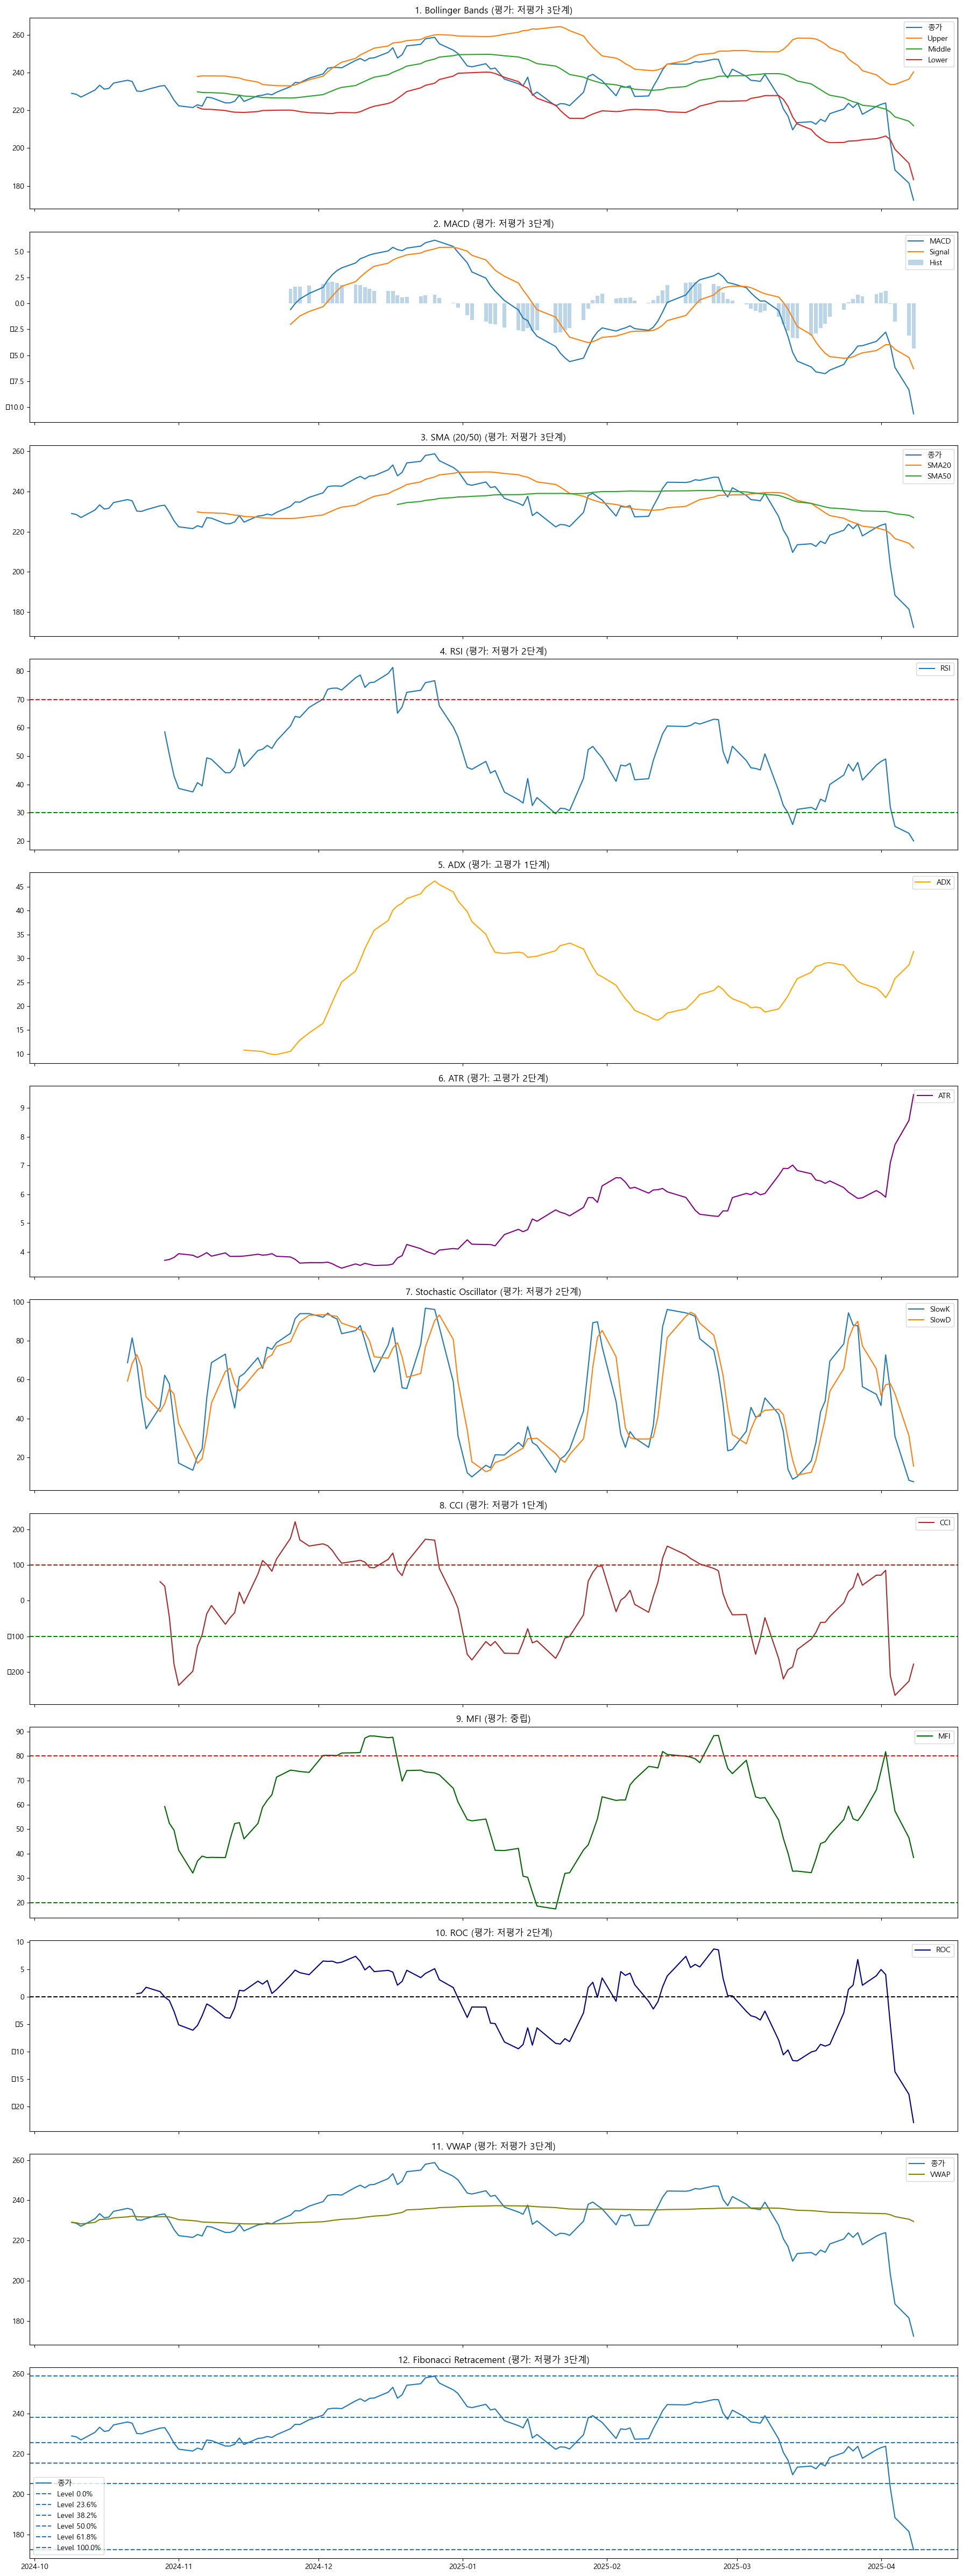

In [7]:
df = get_stock_data("AAPL")
indicators, df = compute_indicators(df)
plot_indicators(indicators, df)

In [9]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Signal'], dtype='object')

In [8]:
# 거래 시그널
df['Signal'] = 0
df.loc[
    (df['MACD'] > df['MACD_signal']) &
    (df['RSI'] > 30) & (df['RSI'] < 70) &
    (df['MFI'] > 50) &
    (df['ATR'] > df['ATR'].rolling(window=14).mean()),
    'Signal'
] = 1

# 백테스트
df['Position'] = df['Signal'].shift(1)
df['Daily Return'] = df['Close'].pct_change()
df['Strategy Return'] = df['Daily Return'] * df['Position']

# 누적 수익률
(1 + df[['Daily Return', 'Strategy Return']]).cumprod().plot(figsize=(14, 7))
plt.title('Strategy Backtest: MACD + RSI + ATR + MFI')
plt.show()


KeyError: 'MACD'